In [1]:
from pathlib import Path

BASE_DIR = Path("e2_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e2_artifacts/logs
/content/e2_artifacts/tables
/content/e2_artifacts/figures
/content/e2_artifacts/reports


In [2]:
import pandas as pd

TRAIN_PATH = "train_final.csv"
TEST_PATH = "test_final.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

train_df shape: (7957, 3)
test_df shape: (2211, 3)


,text,label,id
0,@YELLEZ @WylsacomRed Почему бы просто не купит...,neutral,1215652526319722501
1,"посмотрите кто-нибудь ""импровизацию""..\r\nя хо...",positive,1341141182093668352
2,@robodeacon зашел сфоткаться с кастом тени и к...,neutral,1234077503993581569
3,Моя оформа: /меняется на чёрно-белую/\r\n\r\nМ...,neutral,1326075120465702912
4,сижу в такси рядом ползает паук няшка,positive,1276191130535821315


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041


In [3]:
SEED = 42

X_train = train_df["text"].copy()
y_train = train_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7957,)
y_train: (7957,)
X_test: (2211,)
y_test: (2211,)


In [4]:
import json

E2_CONFIG = {
    "experiment": "E2 feature space study",
    "dataset": "RuSentiTweet",
    "train_file": TRAIN_PATH,
    "test_file": TEST_PATH,
    "seed": SEED,
    "models": [
        "SGDClassifier hinge",
        "RidgeClassifier",
        "Linear SVM"
    ],
    "representations": {
        "word_tfidf": {
            "type": "TfidfVectorizer",
            "lowercase": True,
            "analyzer": "word",
            "ngram_range": (1, 2),
            "min_df": 2,
            "max_df": 0.95
        },
        "char_tfidf": {
            "type": "TfidfVectorizer",
            "lowercase": True,
            "analyzer": "char_wb",
            "ngram_range": (3, 5),
            "min_df": 2,
            "max_df": 0.95
        }
    }
}

with open(LOG_DIR / "e2_config.json", "w", encoding="utf-8") as f:
    json.dump(E2_CONFIG, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "e2_config.json")

Saved: e2_artifacts/logs/e2_config.json


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_word = word_vectorizer.fit_transform(X_train)
X_test_word = word_vectorizer.transform(X_test)

print("X_train_word shape:", X_train_word.shape)
print("X_test_word shape:", X_test_word.shape)

X_train_word shape: (7957, 8037)
X_test_word shape: (2211, 8037)


In [6]:
char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

print("X_train_char shape:", X_train_char.shape)
print("X_test_char shape:", X_test_char.shape)

X_train_char shape: (7957, 78069)
X_test_char shape: (2211, 78069)


In [7]:
import time
from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [8]:
e2_results = []

In [9]:
def evaluate_model(model, model_name, representation_name, X_train_mat, y_train, X_test_mat, y_test, report_filename):
    start_time = time.time()
    model.fit(X_train_mat, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_mat)

    acc = accuracy_score(y_test, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_test, y_pred, average="macro")

    report = classification_report(y_test, y_pred, digits=4)

    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report)

    result = {
        "model": model_name,
        "representation": representation_name,
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "train_time_sec": round(train_time, 4),
        "seed": SEED
    }

    return result, y_pred, report

In [10]:
sgd_hinge_word = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

res_sgd_word, pred_sgd_word, rep_sgd_word = evaluate_model(
    model=sgd_hinge_word,
    model_name="SGDClassifier hinge",
    representation_name="word TF-IDF (1,2)",
    X_train_mat=X_train_word,
    y_train=y_train,
    X_test_mat=X_test_word,
    y_test=y_test,
    report_filename="classification_report_sgd_hinge_word.txt"
)

e2_results.append(res_sgd_word)
print(res_sgd_word)

{'model': 'SGDClassifier hinge', 'representation': 'word TF-IDF (1,2)', 'accuracy': 0.6174, 'precision_weighted': 0.6184, 'recall_weighted': 0.6174, 'weighted_f1': 0.6051, 'macro_f1': 0.5767, 'train_time_sec': 0.1768, 'seed': 42}


In [11]:
sgd_hinge_char = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

res_sgd_char, pred_sgd_char, rep_sgd_char = evaluate_model(
    model=sgd_hinge_char,
    model_name="SGDClassifier hinge",
    representation_name="char TF-IDF (3,5)",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_sgd_hinge_char.txt"
)

e2_results.append(res_sgd_char)
print(res_sgd_char)

{'model': 'SGDClassifier hinge', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.682, 'precision_weighted': 0.6854, 'recall_weighted': 0.682, 'weighted_f1': 0.6741, 'macro_f1': 0.6517, 'train_time_sec': 0.6783, 'seed': 42}


In [12]:
ridge_word = RidgeClassifier()

res_ridge_word, pred_ridge_word, rep_ridge_word = evaluate_model(
    model=ridge_word,
    model_name="RidgeClassifier",
    representation_name="word TF-IDF (1,2)",
    X_train_mat=X_train_word,
    y_train=y_train,
    X_test_mat=X_test_word,
    y_test=y_test,
    report_filename="classification_report_ridge_word.txt"
)

e2_results.append(res_ridge_word)
print(res_ridge_word)

{'model': 'RidgeClassifier', 'representation': 'word TF-IDF (1,2)', 'accuracy': 0.6124, 'precision_weighted': 0.6116, 'recall_weighted': 0.6124, 'weighted_f1': 0.6015, 'macro_f1': 0.5734, 'train_time_sec': 0.2452, 'seed': 42}


In [13]:
ridge_char = RidgeClassifier()

res_ridge_char, pred_ridge_char, rep_ridge_char = evaluate_model(
    model=ridge_char,
    model_name="RidgeClassifier",
    representation_name="char TF-IDF (3,5)",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_ridge_char.txt"
)

e2_results.append(res_ridge_char)
print(res_ridge_char)

{'model': 'RidgeClassifier', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6712, 'precision_weighted': 0.6743, 'recall_weighted': 0.6712, 'weighted_f1': 0.6622, 'macro_f1': 0.6382, 'train_time_sec': 0.8627, 'seed': 42}


In [14]:
svm_word = LinearSVC(random_state=SEED)

res_svm_word, pred_svm_word, rep_svm_word = evaluate_model(
    model=svm_word,
    model_name="Linear SVM",
    representation_name="word TF-IDF (1,2)",
    X_train_mat=X_train_word,
    y_train=y_train,
    X_test_mat=X_test_word,
    y_test=y_test,
    report_filename="classification_report_svm_word.txt"
)

e2_results.append(res_svm_word)
print(res_svm_word)

{'model': 'Linear SVM', 'representation': 'word TF-IDF (1,2)', 'accuracy': 0.6097, 'precision_weighted': 0.6057, 'recall_weighted': 0.6097, 'weighted_f1': 0.6011, 'macro_f1': 0.5737, 'train_time_sec': 0.1391, 'seed': 42}


In [15]:
svm_char = LinearSVC(random_state=SEED)

res_svm_char, pred_svm_char, rep_svm_char = evaluate_model(
    model=svm_char,
    model_name="Linear SVM",
    representation_name="char TF-IDF (3,5)",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_svm_char.txt"
)

e2_results.append(res_svm_char)
print(res_svm_char)

{'model': 'Linear SVM', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6716, 'precision_weighted': 0.6707, 'recall_weighted': 0.6716, 'weighted_f1': 0.6662, 'macro_f1': 0.6452, 'train_time_sec': 0.9798, 'seed': 42}


In [16]:
e2_results_df = pd.DataFrame(e2_results)
e2_results_df = e2_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e2_results_df)

,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed
0,SGDClassifier hinge,"char TF-IDF (3,5)",0.6820,0.6854,0.6820,0.6741,0.6517,0.6783,42
1,Linear SVM,"char TF-IDF (3,5)",0.6716,0.6707,0.6716,0.6662,0.6452,0.9798,42
2,RidgeClassifier,"char TF-IDF (3,5)",0.6712,0.6743,0.6712,0.6622,0.6382,0.8627,42
3,SGDClassifier hinge,"word TF-IDF (1,2)",0.6174,0.6184,0.6174,0.6051,0.5767,0.1768,42
4,RidgeClassifier,"word TF-IDF (1,2)",0.6124,0.6116,0.6124,0.6015,0.5734,0.2452,42
5,Linear SVM,"word TF-IDF (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.1391,42


In [17]:
e2_results_df.to_csv(TABLE_DIR / "e2_feature_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e2_feature_results.csv")

Saved: e2_artifacts/tables/e2_feature_results.csv


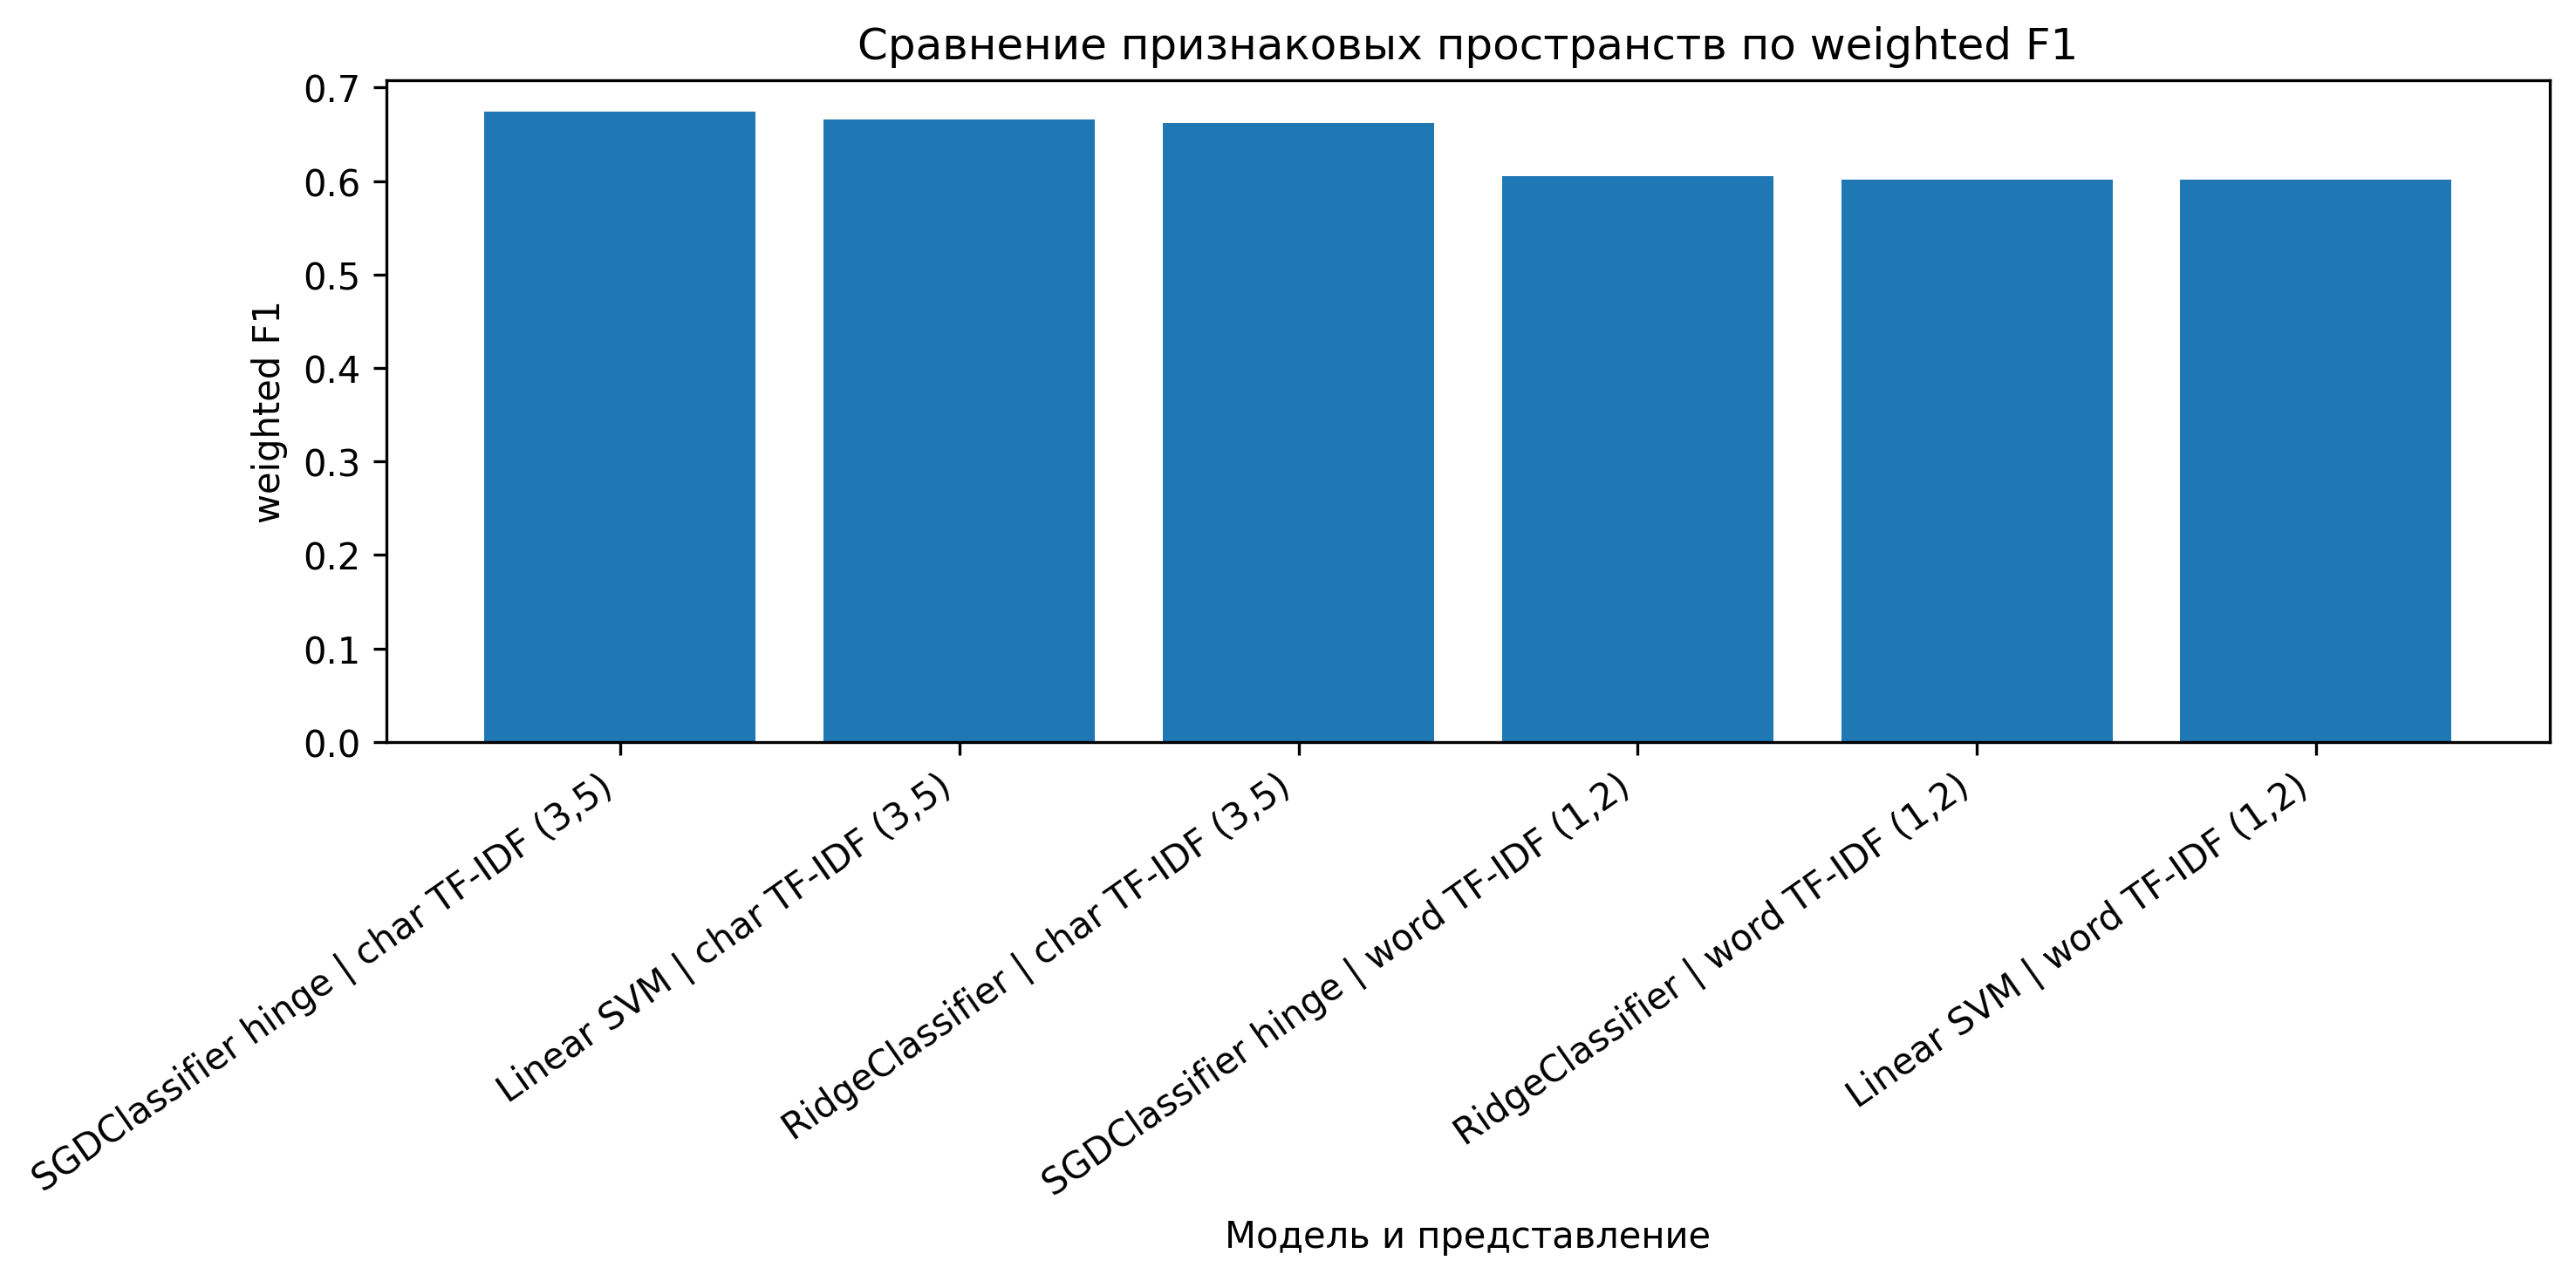

In [18]:
import matplotlib.pyplot as plt

plot_df = e2_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(
    plot_df["model"] + " | " + plot_df["representation"],
    plot_df["weighted_f1"]
)
plt.title("Сравнение признаковых пространств по weighted F1")
plt.xlabel("Модель и представление")
plt.ylabel("weighted F1")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e2_features_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

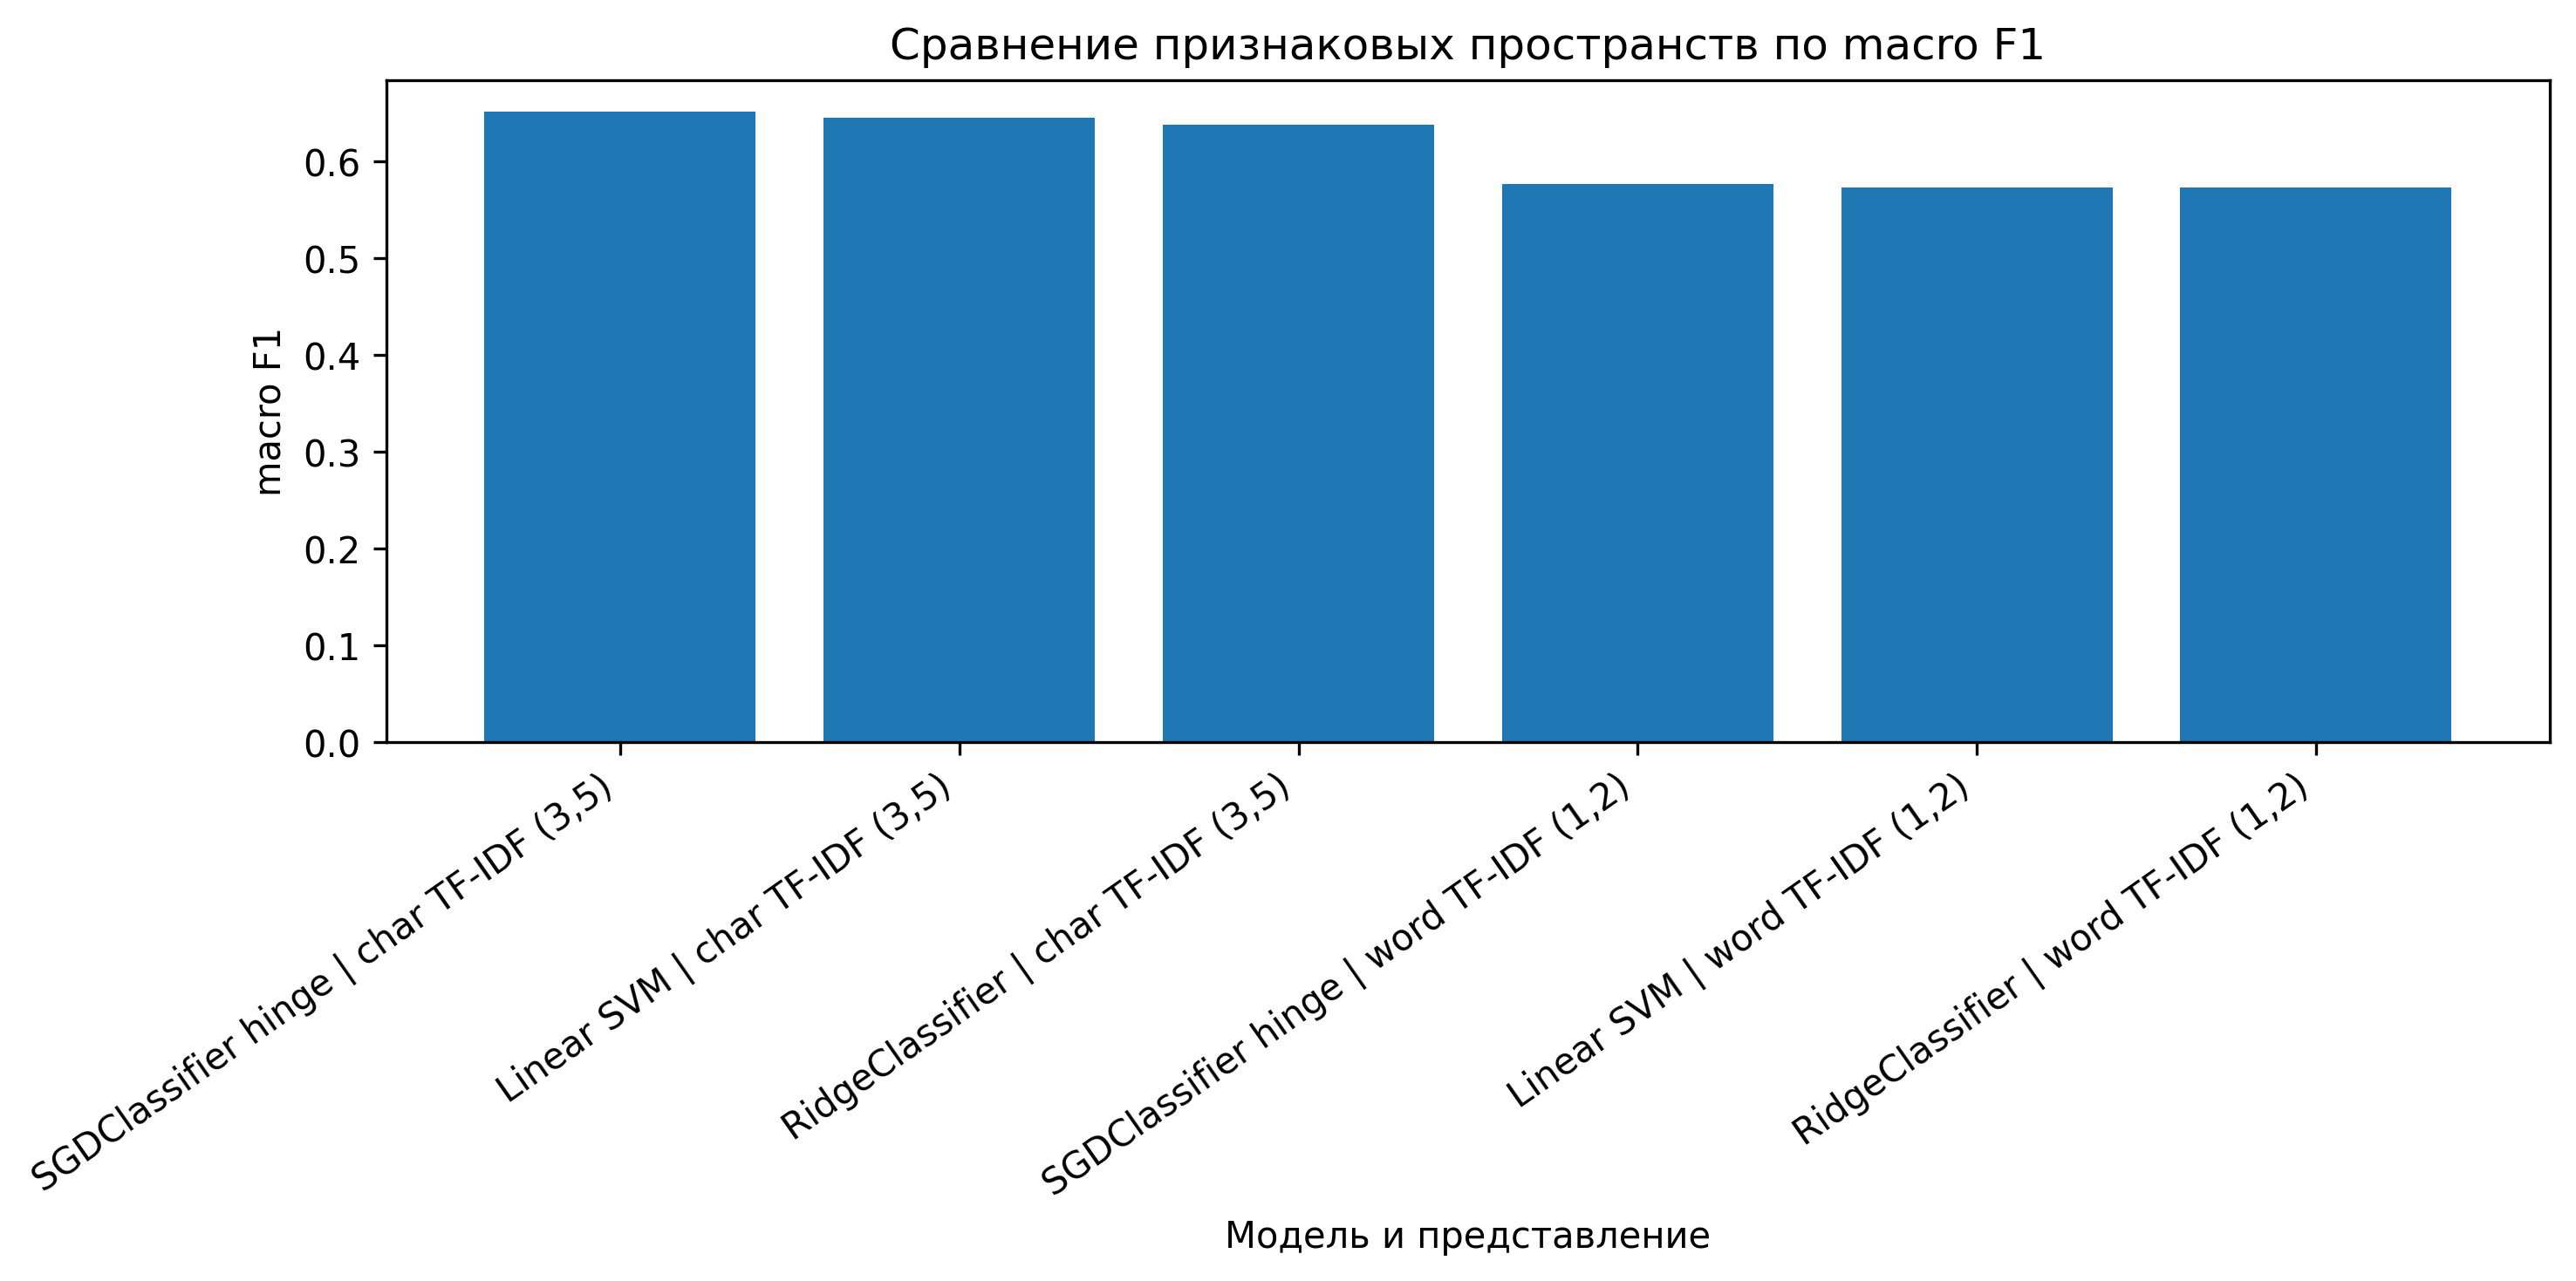

In [19]:
plot_df_macro = e2_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(
    plot_df_macro["model"] + " | " + plot_df_macro["representation"],
    plot_df_macro["macro_f1"]
)
plt.title("Сравнение признаковых пространств по macro F1")
plt.xlabel("Модель и представление")
plt.ylabel("macro F1")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e2_features_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
best_e2_model_name = e2_results_df.iloc[0]["model"]
best_e2_representation = e2_results_df.iloc[0]["representation"]

print("Best E2 model:", best_e2_model_name)
print("Best E2 representation:", best_e2_representation)

Best E2 model: SGDClassifier hinge
Best E2 representation: char TF-IDF (3,5)


In [21]:
predictions_map = {
    ("SGDClassifier hinge", "word TF-IDF (1,2)"): pred_sgd_word,
    ("SGDClassifier hinge", "char TF-IDF (3,5)"): pred_sgd_char,
    ("RidgeClassifier", "word TF-IDF (1,2)"): pred_ridge_word,
    ("RidgeClassifier", "char TF-IDF (3,5)"): pred_ridge_char,
    ("Linear SVM", "word TF-IDF (1,2)"): pred_svm_word,
    ("Linear SVM", "char TF-IDF (3,5)"): pred_svm_char
}

best_e2_pred = predictions_map[(best_e2_model_name, best_e2_representation)]

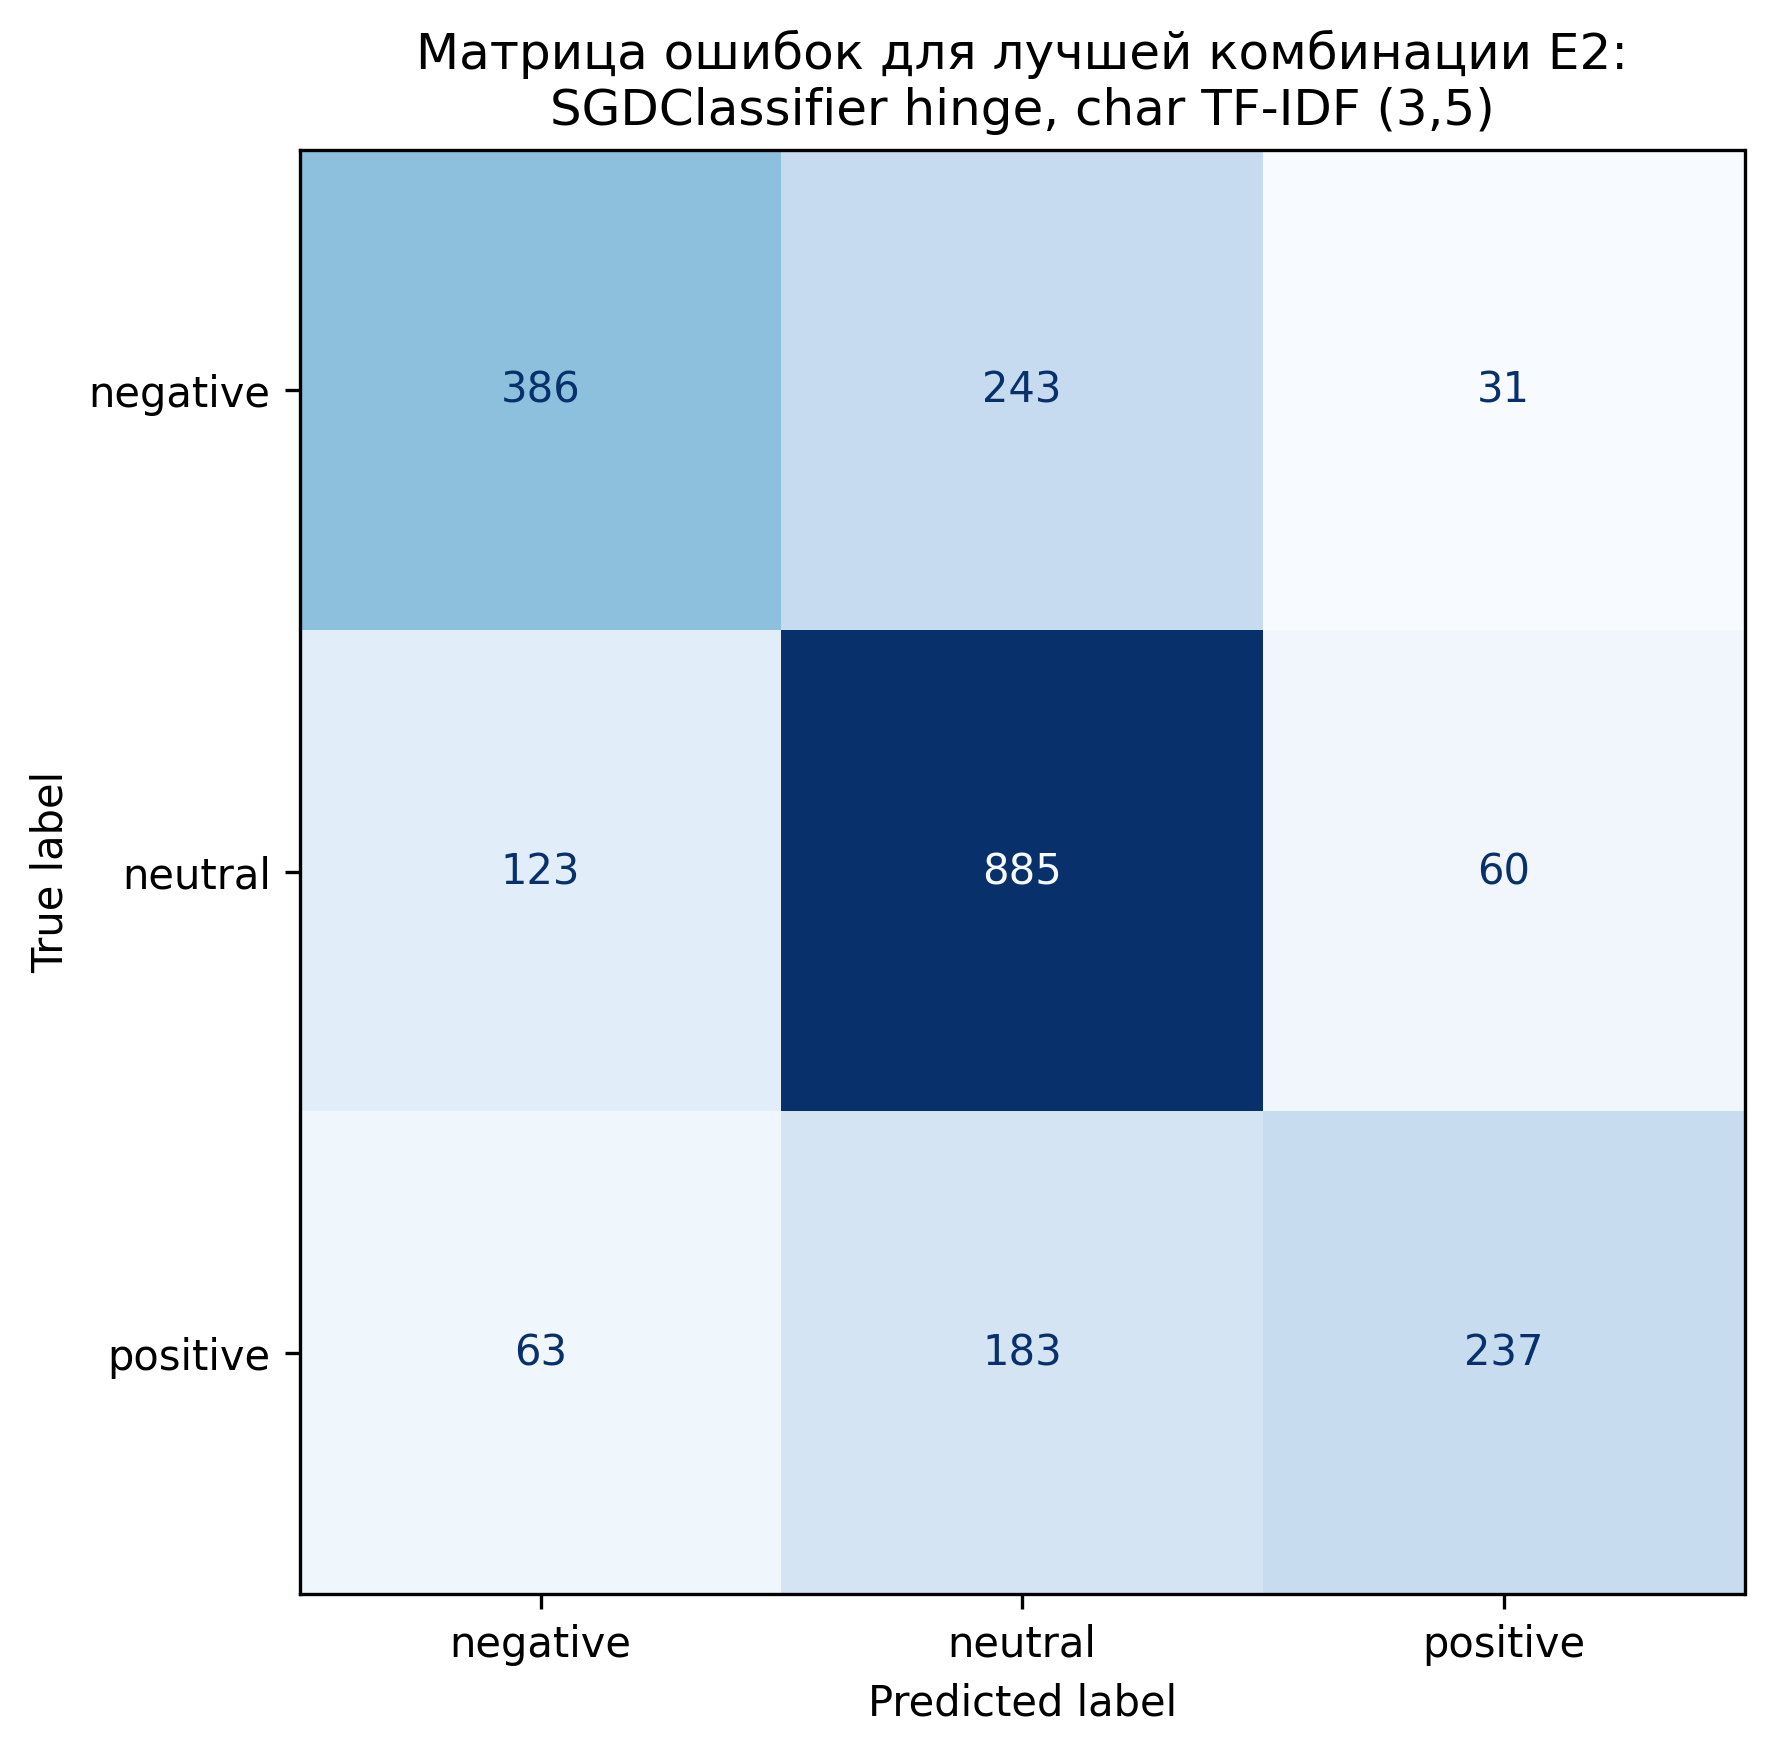

In [22]:
labels_order = ["negative", "neutral", "positive"]

cm_best_e2 = confusion_matrix(y_test, best_e2_pred, labels=labels_order)
disp_best_e2 = ConfusionMatrixDisplay(confusion_matrix=cm_best_e2, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_best_e2.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок для лучшей комбинации E2:\n{best_e2_model_name}, {best_e2_representation}")
plt.tight_layout()
plt.savefig(FIG_DIR / "e2_best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
experiment_ids = [f"E2-{i+1}" for i in range(len(e2_results_df))]

e2_registry = e2_results_df.copy()
e2_registry.insert(0, "experiment_id", experiment_ids)
e2_registry["dataset"] = "RuSentiTweet"
e2_registry["train_split"] = "train_final"
e2_registry["test_split"] = "test_final"
e2_registry["status"] = "completed"

display(e2_registry)

,experiment_id,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,dataset,train_split,test_split,status
0,E2-1,SGDClassifier hinge,"char TF-IDF (3,5)",0.6820,0.6854,0.6820,0.6741,0.6517,0.6783,42,RuSentiTweet,train_final,test_final,completed
1,E2-2,Linear SVM,"char TF-IDF (3,5)",0.6716,0.6707,0.6716,0.6662,0.6452,0.9798,42,RuSentiTweet,train_final,test_final,completed
2,E2-3,RidgeClassifier,"char TF-IDF (3,5)",0.6712,0.6743,0.6712,0.6622,0.6382,0.8627,42,RuSentiTweet,train_final,test_final,completed
3,E2-4,SGDClassifier hinge,"word TF-IDF (1,2)",0.6174,0.6184,0.6174,0.6051,0.5767,0.1768,42,RuSentiTweet,train_final,test_final,completed
4,E2-5,RidgeClassifier,"word TF-IDF (1,2)",0.6124,0.6116,0.6124,0.6015,0.5734,0.2452,42,RuSentiTweet,train_final,test_final,completed
5,E2-6,Linear SVM,"word TF-IDF (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.1391,42,RuSentiTweet,train_final,test_final,completed


In [24]:
e2_registry.to_csv(TABLE_DIR / "e2_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e2_experiment_registry.csv")

Saved: e2_artifacts/tables/e2_experiment_registry.csv


In [25]:
e2_summary = f"""
E2 FEATURE SPACE STUDY SUMMARY

Goal:
Compare word-level and character-level TF-IDF representations
for top classical models on a fixed split.

Dataset:
RuSentiTweet

Train shape:
{train_df.shape}

Test shape:
{test_df.shape}

Models:
- SGDClassifier hinge
- RidgeClassifier
- Linear SVM

Representations:
- word TF-IDF (1,2)
- char TF-IDF (3,5)

Best combination:
model = {best_e2_model_name}
representation = {best_e2_representation}
accuracy = {e2_results_df.iloc[0]["accuracy"]}
weighted_f1 = {e2_results_df.iloc[0]["weighted_f1"]}
macro_f1 = {e2_results_df.iloc[0]["macro_f1"]}

Full ranking:
{e2_results_df[["model", "representation", "accuracy", "weighted_f1", "macro_f1"]].to_string(index=False)}
"""

with open(LOG_DIR / "e2_summary.txt", "w", encoding="utf-8") as f:
    f.write(e2_summary)

print("Saved:", LOG_DIR / "e2_summary.txt")

Saved: e2_artifacts/logs/e2_summary.txt
